# Gradient Descent Optimizer

# Project 9a: Variational Quantum Eigensolver (Gradient-Based)

**Objective:** Use a hybrid quantum-classical loop to find the minimum energy (ground state) of a given molecule or system using a gradient-based optimizer.

**Theory:**
The VQE is the flagship algorithm of the NISQ (Noisy Intermediate-Scale Quantum) era. Instead of requiring millions of error-corrected qubits, it offloads the heavy mathematical lifting to a classical computer. It relies on three parts:
1. **The Hamiltonian:** A mathematical representation of the energy of our system (e.g., a molecule).
2. **The Ansatz:** A parameterized quantum circuit (like a neural network with adjustable weights/angles).
3. **The Loop:** The quantum computer measures the energy of the current Ansatz. The classical computer (using Python's SciPy) calculates the gradient, adjusts the parameters to lower the energy, and feeds them back into the quantum circuit.

In this notebook, we will use the `SLSQP` (Sequential Least Squares Programming) optimizer, which relies on calculating gradients to find the minimum energy state.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

print("Environment Ready.")

Environment Ready.


## Step 1: Defining the Hamiltonian and the Ansatz

First, we define our target system. We will create a simple 2-qubit Hamiltonian using Pauli operators ($Z$ and $X$). 

Next, we define our **Ansatz**. We use Qiskit's `EfficientSU2`, which is a pre-built, hardware-efficient heuristic circuit. It lays down a pattern of $R_y$ and $R_z$ rotation gates intertwined with entanglement gates. The angles of these rotations are the variables our classical computer will be tweaking.

/tmp/ipykernel_19456/451513165.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=2, reps=1, entanglement='linear')


Number of parameters to optimize: 8
Ansatz Architecture:


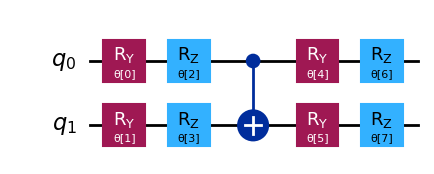

In [2]:
# 1. Define the observable we want to minimize (The Hamiltonian)
hamiltonian = SparsePauliOp.from_list([("ZZ", 1.0), ("ZI", -0.5), ("IX", 0.2)])

# 2. Define the parameterized quantum circuit (The Ansatz)
ansatz = EfficientSU2(num_qubits=2, reps=1, entanglement='linear')

print(f"Number of parameters to optimize: {ansatz.num_parameters}")
print("Ansatz Architecture:")
display(ansatz.decompose().draw('mpl'))

## Step 2: The Hybrid Optimization Loop

We will use the modern **V2 `StatevectorEstimator`** primitive. Unlike the Sampler (which counts 0s and 1s), the Estimator directly calculates the expectation value (the average energy) of an observable.

We wrap this quantum execution inside a standard Python `cost_function`. We then pass this function to SciPy's `minimize` method, starting with random angles. The classical optimizer will repeatedly call the quantum circuit, evaluate the energy, calculate the slope (gradient), and step "downhill" until it bottoms out.

In [3]:
# Initialize the V2 Estimator
estimator = StatevectorEstimator()

# Array to store energy history for plotting
energy_history = []

def cost_function(params):
    """Executes the quantum circuit and returns the expectation value (energy)."""
    # V2 Estimator PUB format: (circuit, observable, parameters)
    pub = (ansatz, hamiltonian, params)
    
    # Run the estimator
    job = estimator.run([pub])
    result = job.result()[0]
    
    # Extract the energy (expectation value)
    energy = result.data.evs
    energy_history.append(energy)
    
    return energy

# Set random initial parameters
initial_parameters = np.random.rand(ansatz.num_parameters) * 2 * np.pi

print("Starting VQE Optimization with SLSQP (Gradient-Based)...")

# Run the classical optimizer
result_slsqp = minimize(cost_function, initial_parameters, method='SLSQP', options={'maxiter': 100})

print("\n--- Optimization Complete ---")
print(f"Optimal Parameters: {result_slsqp.x}")
print(f"Ground State Energy: {result_slsqp.fun}")

Starting VQE Optimization with SLSQP (Gradient-Based)...

--- Optimization Complete ---
Optimal Parameters: [3.14169266 3.14174756 5.19681389 4.23261232 6.48053151 6.28323087
 6.27907984 2.74853818]
Ground State Energy: -1.519803542866383


## Step 3: Visualizing the Gradient Descent

Let's plot the energy history recorded during our classical-quantum loop to visualize how quickly SLSQP found the ground state.

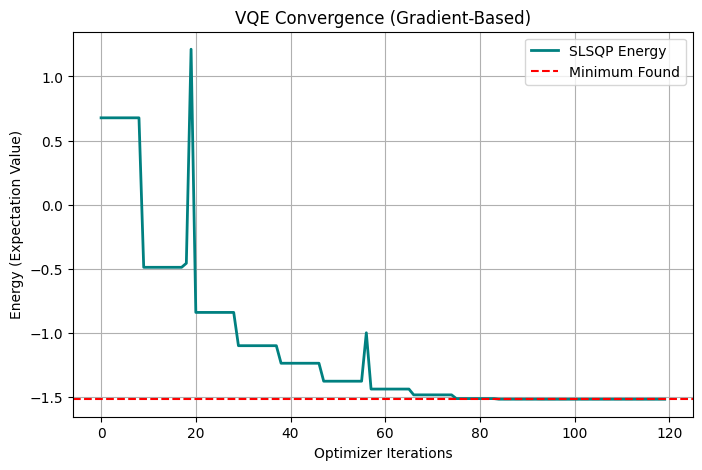

In [4]:
# Plot the convergence over time
plt.figure(figsize=(8, 5))
plt.plot(energy_history, color='teal', linewidth=2, label="SLSQP Energy")
plt.axhline(y=result_slsqp.fun, color='red', linestyle='--', label="Minimum Found")
plt.title("VQE Convergence (Gradient-Based)")
plt.xlabel("Optimizer Iterations")
plt.ylabel("Energy (Expectation Value)")
plt.legend()
plt.grid(True)
plt.show()

## Final Analysis
**What did we just observe?**
The graph shows a smooth, steep drop in energy. Because SLSQP calculates gradients (the mathematical slope of the energy landscape), it quickly determines exactly which direction to "step" to lower the energy. The classical Python loop iteratively rotated the quantum gates until it found the absolute minimum possible output for our Hamiltonian.